In [14]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import rcParams

In [15]:
bias_type = "none"
bias_strength = "0.0"
dataset = "gbs_allensbach"
method = "fw-mrs-temperature"
fixed_hyperparameter = "0.01"

In [16]:
overlapping_allensbach_columns = [
        "Age",
        "Occupational Group",
        "Employment Status",
        "Sex",
        "Optimism",
        "Pessimism",
        "School Degree",
        "Weekly Working Hours",
        "Resilience",
    ]

In [17]:
method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
feature_importances/feature_importances.json")
with open(method_path) as file:
    method_feature_importance_list = np.array(json.load(file))[:10]

In [18]:
feature_importances = []
for method_feature_importance in method_feature_importance_list:
    feature_importances.append(method_feature_importance["0.0"][fixed_hyperparameter])

In [19]:
feature_importances_df = pd.DataFrame(feature_importances)
feature_importances_df.columns = overlapping_allensbach_columns
order = feature_importances_df[overlapping_allensbach_columns].mean().sort_values(ascending=False).index

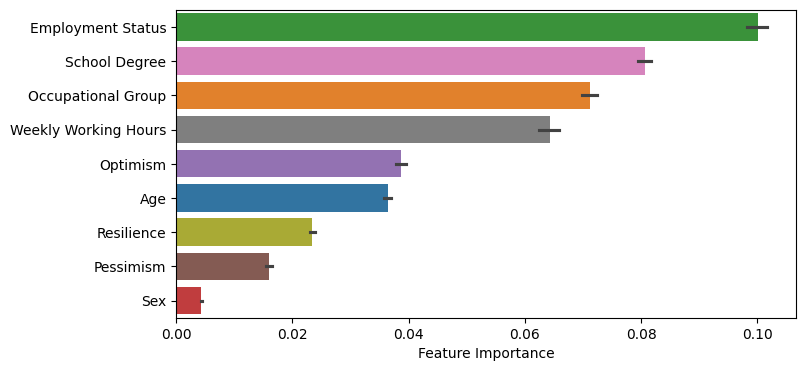

In [20]:
# figure size in inches
rcParams['figure.figsize'] = 8,4

ax = sns.barplot(feature_importances_df, orient="y", order=order)
ax.set(xlabel="Feature Importance")
ax.get_figure().savefig("gbs_allensbach_feature_importances.pdf", bbox_inches='tight', pad_inches=0) 

In [21]:
method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
feature_weights/weights.json")
with open(method_path) as file:
    method_feature_weights_list = np.array(json.load(file))[:10]

In [22]:
feature_weights = []
for method_feature_weights in method_feature_weights_list:
    for key in method_feature_weights.keys():
        feature_weights.append(method_feature_weights[key][fixed_hyperparameter])

In [23]:
feature_weights_df = pd.DataFrame(feature_weights)
feature_weights_df.columns = overlapping_allensbach_columns
feature_weights_df["Temperature"] = np.array([list(method_feature_weights.keys()) for method_feature_weights in method_feature_weights_list]).flatten().astype(float)
order = feature_weights_df[overlapping_allensbach_columns].mean().sort_values(ascending=False).index

In [24]:
melted_feature_weights_df = pd.melt(feature_weights_df, id_vars="Temperature", value_vars=overlapping_allensbach_columns)
melted_feature_weights_df["Temperature"] = melted_feature_weights_df["Temperature"].astype("category")

In [25]:
melted_feature_weights_df

,Temperature,variable,value
0,0.0000,Age,1.111111e-01
1,0.5000,Age,1.132597e-01
2,0.2500,Age,1.150048e-01
3,0.1000,Age,1.177459e-01
4,0.0500,Age,1.144832e-01
...,...,...,...
895,0.0250,Resilience,1.682556e-01
896,0.0100,Resilience,1.055007e-01
897,0.0050,Resilience,2.411712e-02
898,0.0025,Resilience,7.441863e-04


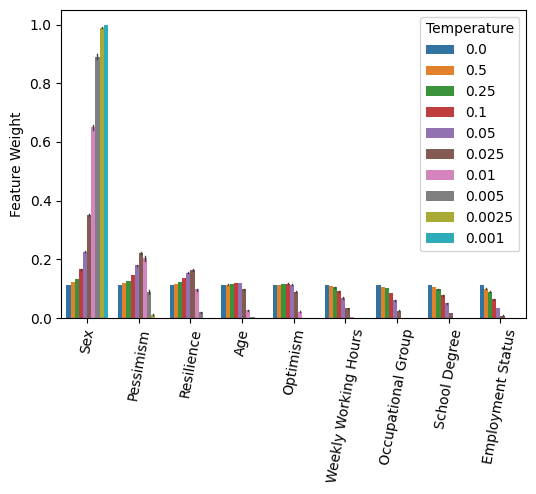

In [29]:
hue_order = [0.0, 0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.005, 0.0025, 0.001]
rcParams['figure.figsize'] = 6,4

ax = sns.barplot(melted_feature_weights_df, y="value", x="variable", hue="Temperature", order=order,
                 hue_order=hue_order, err_kws={'linewidth': 1})
ax.set(ylabel="Feature Weight", xlabel="")
ax.tick_params(axis='x', rotation=80)
ax.get_figure().savefig("gbs_allensbach_feature_weights.pdf", bbox_inches='tight', pad_inches=0) 

In [27]:
method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
optimised_mmd.json")
with open(method_path) as file:
    method_mmd_list = json.load(file)[:10]

KeyError: slice(None, 10, None)

In [ ]:
for key, values in method_mmd_list.items():
    print(f"{key}: {np.round(np.mean(values), 3)} +- {np.round(np.std(values), 3)}")

0.0: 0.153 +- 0.004
0.5: 0.151 +- 0.004
0.25: 0.145 +- 0.003
0.1: 0.132 +- 0.005
0.05: 0.114 +- 0.004
0.025: 0.086 +- 0.002
0.01: 0.059 +- 0.001
0.005: 0.039 +- 0.002
0.0025: 0.034 +- 0.002
0.001: 0.032 +- 0.001


In [ ]:
method_path = Path(f"../results/temperature_comparison/{dataset}/{bias_type}/{bias_strength}/{method}/\
dropped_elements.json")
with open(method_path) as file:
    method_dropped_list = json.load(file)[:10]

In [ ]:
for key, values in method_dropped_list.items():
    print(f"{key}: {np.round(np.mean(values), 1)} +- {np.round(np.std(values), 1)}")

0.0: 501.1 +- 4.9
0.5: 501.0 +- 3.6
0.25: 497.5 +- 3.6
0.1: 493.2 +- 4.2
0.05: 478.7 +- 5.1
0.025: 444.5 +- 4.9
0.01: 305.8 +- 12.7
0.005: 235.8 +- 15.3
0.0025: 152.2 +- 9.7
0.001: 143.0 +- 7.6
